In [ ]:
%gui qt

import pyvista as pv

sphere = pv.Sphere()

plotter = pv.Plotter()
plotter.add_mesh(sphere)

plotter.show()

In [ ]:
%gui qt

import mne
mne.viz.set_3d_backend("notebook")

import pickle
import helpers.helper_functions as hf
import os.path as op

print(mne.viz.get_3d_backend())

ss = hf.settings_dict()

with open(op.join(ss['sensor_dir'], 'sensor_dict.p'), 'rb') as fp:
    sensor_dict = pickle.load(fp)

raw = hf.load_raw(subject=1, preload=True)

raw_sub = raw.copy().pick([
    'MEG1922', 'MEG1923',
    'MEG2032', 'MEG2033',
    'MEG2042', 'MEG2043',
    'MEG2112', 'MEG2113',
    'MEG2342', 'MEG2343'
])

fig = mne.viz.plot_alignment(
    raw_sub.info,
    meg=True,
    coord_frame='head'
)

fig.plotter.show()

Opening raw data file /media/elias/Personal Data/Documents/masters/Thesis/data/raw/0002/20180522_000000/MEG/001.s2/files/s2.fif...
    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 93000 ... 1274999 =     46.500 ...   637.500 secs
Ready.
Reading 0 ... 1181999  =      0.000 ...   591.000 secs...


/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:42: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/raw/0002/20180522_000000/MEG/001.s2/files/s2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_fname1, preload=preload)  # raw meg data
/home/elias/Workspace/thesis/iliasgdk_thesis/src/helpers/helper_functions.py:50: RuntimeWarning: The unit for channel(s) MISC001 has changed from V to NA.
  raw.set_channel_types(mapping={'MISC001': 'misc'})


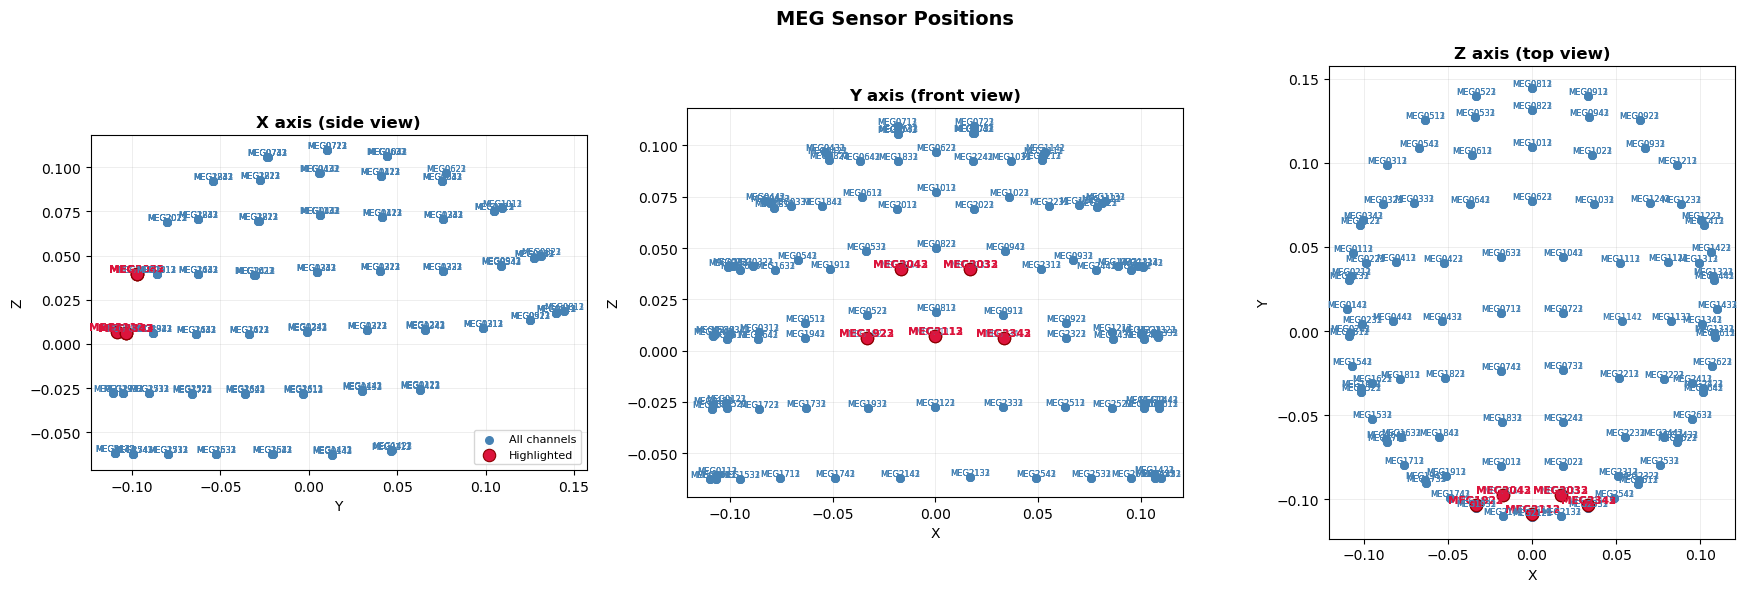

In [4]:
import helpers.helper_functions as hf
raw = hf.load_raw(subject=1, preload=True)

import mne
import matplotlib.pyplot as plt
import numpy as np

raw.pick(picks=["meg"])

info = raw.info

picks = mne.pick_types(info, meg=True)
ch_pos = np.array([info['chs'][i]['loc'][:3] for i in picks])
ch_names = [info['ch_names'][i] for i in picks]

x, y, z = ch_pos[:, 0], ch_pos[:, 1], ch_pos[:, 2]

# --- Subset to highlight ---
highlight = [
    'MEG1922', 'MEG1923',
    'MEG2032', 'MEG2033',
    'MEG2042', 'MEG2043',
    'MEG2112', 'MEG2113',
    'MEG2342', 'MEG2343'
]
is_highlight = np.array([name in highlight for name in ch_names])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

views = [
    (y, z, 'X axis (side view)',  'Y', 'Z'),
    (x, z, 'Y axis (front view)', 'X', 'Z'),
    (x, y, 'Z axis (top view)',   'X', 'Y'),
]

for ax, (h, v, title, xlabel, ylabel) in zip(axes, views):

    # Plot normal channels
    ax.scatter(h[~is_highlight], v[~is_highlight],
               s=30, color='steelblue', zorder=3, label='All channels')

    # Plot highlighted channels on top
    ax.scatter(h[is_highlight], v[is_highlight],
               s=80, color='crimson', zorder=5,
               edgecolors='darkred', linewidths=0.8, label='Highlighted')

    # Channel name labels
    for i, name in enumerate(ch_names):
        color = 'crimson' if is_highlight[i] else 'steelblue'
        fontsize = 6 if not is_highlight[i] else 7.5
        fontweight = 'bold' if is_highlight[i] else 'normal'
        ax.text(h[i], v[i], name,
                fontsize=fontsize, color=color,
                fontweight=fontweight,
                ha='center', va='bottom', zorder=6)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='lower right', fontsize=8)
plt.suptitle('MEG Sensor Positions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()